In [ ]:
# esta celda controla el estilo del cuaderno
from IPython.core.display import HTML
def css_styling():
    styles = open("custom.css", "r").read()
    return HTML(styles)
css_styling()

# Vectores de Palabras y Modelos de Lenguaje

## Introducción

Gran parte de los avances recientes en el mundo del Procesamiento del Lenguaje Natural están ligados a mejoras en la forma en la que introducimos y representamos palabras, oraciones y significados dentro de un ordenador. Las máquinas son incapaces de manejar los significados de las palabras ni las relaciones que se establecen entre ellas a menos que seamos capaces de convertir palabras y conceptos en representaciones numéricas con el ordenador pueda operar.

En este segundo cuaderno profundizaremos en los distintos mecanismos que tenemos para generar y utilizar estas representaciones numéricas, conocidas con el nombre de vectores de palabras o *embeddings*, y aprenderás a utilizar los últimos modelos de lenguaje para hacer que las máquinas manejen significados y conceptos.

## ¿Cómo representamos palabras, oraciones y significados en NLP?

Ya hemos visto en la anterior nota que el primer paso para procesar lenguaje natural es segmentar el texto en unidades. Estas unidades suelen coincidir con la idea intuitiva que tenemos de una palabbra.

Pero cuando hablamos de *palabras*, podemos distinguir dos conceptos diferentes:

- **ocurrencia** (*token*) se refiere a una observación de una palabra en una cadena de texto. 

    Como hemos visto, en algunas lenguas es más o menos complejo identificar los límites de las palabras, pero en la mayoría de las lenguas occidentales y de nuestro entorno se utilizan espacios y otros signos de puntuación para delimitar las palabras.

- **tipo** (*type*) es la representación abstracta de una palabra. Cada **ocurrencia** pertenece a un **tipo** de palabra. 

    Cuando contamos la frecuencia de las palabras de una colección de documentos (o *corpus*), lo que hacemos es contar el número de ocurrencias que tiene cada tipo.
    
Ya hemos visto cómo podemos tokenizar un texto con `spaCy`:

In [ ]:
# instalamos spacy
#!pip install -U spacy

# y descargamos un modelo pre-entrenado para inglés
#!python -m spacy download es_core_news_md
#!pip install pandas

In [1]:
import warnings
warnings.filterwarnings("ignore")

import spacy

from typing import List

nlp = spacy.load("es_core_news_md")

def tokenize(text: str) -> List[str]:
    """Returns a list of tokens as provided by spaCy"""
    doc = nlp(text)
    return [token.text for token in doc]

In [2]:
textos = [
    """No hubo sorpresa en Bruselas. 621 votos a favor, 49 en contra (los 'remainers' británicos entre ellos) y 13 abstenciones.""",
    """Los senadores interrogan a los jefes de Twitter, Facebook y Google sobre su sesgo político y su permeabilidad a las noticias falsas, en una politizada audiencia a seis días de las elecciones.'""",
    """Los postes de pared ID. Charger para el hogar permiten conectar tu ID.3 para llenar sus baterías al completo durante la noche.""",
]

tweets = [
    """🎉¡#SORTEO! Gana una tostadora YummyToast Double. 🎁 
▪️Síguenos. 
▪️Comenta mencionando a 2 amigos junto a #Cecotec.
Tienes hasta el 9 de febrero para participar. El regalo se sorteará aleatoriamente entre los participantes. ¡Mucha suerte!.""",
    """Jugamos para todos ustedes 🏀‼️🖤 https://t.co/sd12vW93 #MambaMentality""",
]

In [3]:
for text in textos + tweets:
    print(tokenize(text))

['No', 'hubo', 'sorpresa', 'en', 'Bruselas', '.', '621', 'votos', 'a', 'favor', ',', '49', 'en', 'contra', '(', 'los', "'", 'remainers', "'", 'británicos', 'entre', 'ellos', ')', 'y', '13', 'abstenciones', '.']
['Los', 'senadores', 'interrogan', 'a', 'los', 'jefes', 'de', 'Twitter', ',', 'Facebook', 'y', 'Google', 'sobre', 'su', 'sesgo', 'político', 'y', 'su', 'permeabilidad', 'a', 'las', 'noticias', 'falsas', ',', 'en', 'una', 'politizada', 'audiencia', 'a', 'seis', 'días', 'de', 'las', 'elecciones', '.', "'"]
['Los', 'postes', 'de', 'pared', 'ID', '.', 'Charger', 'para', 'el', 'hogar', 'permiten', 'conectar', 'tu', 'ID.3', 'para', 'llenar', 'sus', 'baterías', 'al', 'completo', 'durante', 'la', 'noche', '.']
['🎉', '¡', '#', 'SORTEO', '!', 'Gana', 'una', 'tostadora', 'YummyToast', 'Double', '.', '🎁', '\n', '▪', '️Síguenos', '.', '\n', '▪', '️Comenta', 'mencionando', 'a', '2', 'amigos', 'junto', 'a', '#', 'Cecotec', '.', '\n', 'Tienes', 'hasta', 'el', '9', 'de', 'febrero', 'para', 'part

## Representaciones discretas: cadenas o números enteros

A partir de aquí vamos a asumir que tenemos solucionado el proceso de tokenización e identificación de lo que es una palabra. ¿Cómo continuamos?

La manera más sencilla de representar una palabra es como una cadena, es decir, como una secuencia ordenada de caracteres. Esto es cómodo, pero implica dos cosas:

- La cantidad de memoria que ocupa cada cada palabra varía en función de la longitud :-/

- Comprobar si dos palabras son idénticas es un proceso lento :-(

Así que es habitual utilizar otra opción alternativa que consiste en representar las palabras como números enteros, de manera que a cada palabra se le asigna de manera más o menos arbitraria un número entero positivo.

![](https://raw.githubusercontent.com/vitojph/1dlstr-embeddings/main/img/words-indexes.jpg)

In [ ]:
#!pip install -U scikit-learn
#!pip install -U numpy

Podemos ilustrar este proceso de codificación de los tokens como enteros con muy pocas líneas de código. Primero, tokenizamos nuestros tweets:

In [4]:
tweets_tokens = []
tweets_tokens.extend([tokenize(tweet) for tweet in tweets][0])
print(tweets_tokens)

['🎉', '¡', '#', 'SORTEO', '!', 'Gana', 'una', 'tostadora', 'YummyToast', 'Double', '.', '🎁', '\n', '▪', '️Síguenos', '.', '\n', '▪', '️Comenta', 'mencionando', 'a', '2', 'amigos', 'junto', 'a', '#', 'Cecotec', '.', '\n', 'Tienes', 'hasta', 'el', '9', 'de', 'febrero', 'para', 'participar', '.', 'El', 'regalo', 'se', 'sorteará', 'aleatoriamente', 'entre', 'los', 'participantes', '.', '¡', 'Mucha', 'suerte', '!', '.']


Y después creamos una especie de índice para asociar cada token con el entero que lo representa.

In [5]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

tokens_int = label_encoder.fit_transform(tweets_tokens)
token2int = dict(zip(tweets_tokens, tokens_int))

print(token2int)

{'🎉': 39, '¡': 34, '#': 2, 'SORTEO': 11, '!': 1, 'Gana': 9, 'una': 33, 'tostadora': 32, 'YummyToast': 13, 'Double': 7, '.': 3, '🎁': 38, '\n': 0, '▪': 35, '️Síguenos': 37, '️Comenta': 36, 'mencionando': 24, 'a': 14, '2': 4, 'amigos': 16, 'junto': 22, 'Cecotec': 6, 'Tienes': 12, 'hasta': 21, 'el': 18, '9': 5, 'de': 17, 'febrero': 20, 'para': 25, 'participar': 27, 'El': 8, 'regalo': 28, 'se': 29, 'sorteará': 30, 'aleatoriamente': 15, 'entre': 19, 'los': 23, 'participantes': 26, 'Mucha': 10, 'suerte': 31}


Si lo piensas un poco, verás que este tipo de representación tiene varias ventajas e inconvenientes:

- Todos las palabras ocupan la misma cantidad de memoria :-|

- Comprobar si dos cadenas son la misma palabra es rápido :-)

- Estos identificadores arbitrarios no significan nada :-(

- No hay manera de relacionar palabras similares atendiendo a su identificador :-(

## Palabras como vectores *one hot*

Cuando tenemos un mapeo como el anterior entre palabras y enteros, podemos representar cada palabra como un vector *one hot* de $n$ dimensiones, donde $n$ es el tamaño de vocabulario que manejamos. Estos vectores contendrán $0$ en todas sus dimensiones excepto en la posición que coincida con el índice de la palabra en el vocabulario, que contendrá un $1$.

![](https://raw.githubusercontent.com/vitojph/1dlstr-embeddings/main/img/one-hot-vectors.png)

La conversión de enteros a vectores *one hot* es muy sencilla, y probablemente la has usado alguna vez para codificar datos categóricos.

In [6]:
from sklearn.preprocessing import OneHotEncoder

onehot_encoder = OneHotEncoder(sparse=False)

tokens_int = tokens_int.reshape(len(tokens_int), 1)
onehot_tokens = onehot_encoder.fit_transform(tokens_int)

for token in ["🎉", "SORTEO", "los"]:
    print(f"""{token} ==> {onehot_tokens[token2int[token]]} """)

🎉 ==> [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] 
SORTEO ==> [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.] 
los ==> [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] 


Si te fijas, esta representación en realidad no es muy diferente de la anterior que mapeaba palabras como números enteros. Aunque es muy útil en otros contextos, aquí nos enfrentamos con varios problemas: dispersión y espacio requerido para poder almacenar el vocabulario de una colección de documentos mínimamente grande.

Pero el mayor inconveniente de este tipo de representación a la hora de manejar lenguaje natural es la falta de **similitud**. En NLP, hay muchos problemas que queremos resolver y que están relacionados con esta idea de que dos palabras, dos traducciones, dos documentos pueden ser similares. Esto puede parecer trivial para los seres humanos, que no solemos tener dificultades para detectar que dos oraciones, por ejemplo, son similares aunque no compartan vocabulario porque se refieren a lo mismo, o son equivalentes, o hablan de los mismos temas.

Desde el punto de vista algebraico, existe una técnica sencilla para calcular distancias entre vectores y medir el grado de similitud: el **producto escalar**. El producto escalar de dos vectores es tanto mayor cuanto más similares sean. Pero en el caso de estas representaciones *one hot*, como cualquier par de vectores de este tipo son ortogonales, el resultado del producto escalar es siempre $0$.

Por lo tanto, necesitamos otros mecanismos más sofisticados para vectorizar palabras, textos y colecciones de documentos. Prosigamos con nuestro viaje y veamos otro ejemplo con colecciones de documentos.

## Vectorizando colecciones de documentos

Tras la prueba inicial, cargamos un famoso dataset que contiene conversaciones en inglés provenientes de grupos de discusión, organizadas por categoría, y elegimos cuatro temáticas dispares.

In [7]:
import numpy as np

from sklearn.datasets import fetch_20newsgroups

categories = ["comp.windows.x", "rec.sport.baseball", "sci.space", "talk.religion.misc"]
remove = ("headers", "footers", "quotes")

newsgroups_train = fetch_20newsgroups(
    subset="train", categories=categories, remove=remove
)

# tenemos más de 2000 documentos diferentes
print(newsgroups_train.filenames.shape)

(2160,)


Convertimos los documentos a vectores de frecuencias. Los vectores resultantes tienen tantas dimensiones como tokens diferentes contenga la colección de documentos procesada.

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

# los textos son en inglés y en el cálculo de frencuencias vamos a ignorar las stopwords, es decir,
# algunas palabras muy frecuentes (determinantes, preposiciones) pero que no aportan contenido semántico 
vectorizer = CountVectorizer(stop_words="english")
vectors = vectorizer.fit_transform(newsgroups_train.data)
vocab = np.array(vectorizer.get_feature_names())

print(f"dimensiones del vocabulario: {vocab.shape}")
print(f"dimensiones de los vectores: {vectors.shape}") # (documentos, vocabulario)

dimensiones del vocabulario: (27369,)
dimensiones de los vectores: (2160, 27369)


Acabamos de convertir nuestra collección de mensajes original en una gran matriz de datos donde los documentos se representan como vectores de enteros. Cada fila es un documento, cada columna es un elemento del vocabulario, ordenados alfabéticamente. Cada magnitud de una dimensión indica la frecuencia del token en el documento. Pero si reflexionas un poco acerca de cómo se distribuyen las palabras de una lengua, descubrirás que estas representaciones siguen siendo muy dispersas. La mayoría de los documentos contienen solo un subconjunto del vocabulario, por lo que la mayor parte de las dimensiones serán ceros.

In [9]:
import pandas as pd

tokens = vectorizer.get_feature_names()
counts_df = pd.DataFrame(data = vectors.toarray(), columns=tokens)

print(f"tokens: {len(list(counts_df))}")
print(f"documentos: {len(counts_df)}")

tokens: 27369
documentos: 2160


In [10]:
counts_df[["bat", "god", "shuttle", "desktop"]].sample(20)

,bat,god,shuttle,desktop
229,0,0,0,0
282,0,0,0,0
1135,0,0,0,1
1271,0,0,0,0
2141,0,0,0,0
1427,0,0,0,0
681,0,0,0,0
675,0,0,0,0
932,0,0,0,0
385,0,0,0,0


## Refinando los pesos de los términos con tf-idf

[tf-idf](https://en.wikipedia.org/wiki/Tf%E2%80%93idf) (*Term Frequency - Inverse Document Frequency*), introducido por Karen SpärckJones en 1972, es uno de los esquemas de pesados más famosos en tareas de NLP como la recuperación de información y en minería de textos porque permite representar la _importancia_ de un término en el contexto de un documento concreto cuando manejamos un corpus heterogéneo de documentos.

Como su nombre indica, es un término es el producto de dos estadísticas: la frecuencia total del término y el número de documentos de la colección que contiene el término. Por lo tanto, el peso tf-idf de una palabra será:

- tanto mayor cuantas más ocurrencias haya en un corpus
- tanto menor cuantos más documentos lo incluyan

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

docs = [
    "the new york post is a newspaper",
    "I work at the new york times",
    "los angeles times",
    "this is a session on natural language processing"
]

tfidf_encoder = TfidfVectorizer()
vectors = tfidf_encoder.fit_transform(docs)
vocab = np.array(tfidf_encoder.get_feature_names())

print(f"dimensiones del vocabulario: {vocab.shape}")
print(f"dimensiones de los vectores: {vectors.shape}") # (documentos, vocabulario)

dimensiones del vocabulario: (17,)
dimensiones de los vectores: (4, 17)


In [12]:
for i, vector in enumerate(vectors):
    print(f"text: {docs[i]}")
    
    for j, item in enumerate(vocab):
        print(f"\t{item}: {vector.toarray()[0][j]}")
    print()

text: the new york post is a newspaper
	angeles: 0.0
	at: 0.0
	is: 0.3722248517590162
	language: 0.0
	los: 0.0
	natural: 0.0
	new: 0.3722248517590162
	newspaper: 0.47212002654617047
	on: 0.0
	post: 0.47212002654617047
	processing: 0.0
	session: 0.0
	the: 0.3722248517590162
	this: 0.0
	times: 0.0
	work: 0.0
	york: 0.3722248517590162

text: I work at the new york times
	angeles: 0.0
	at: 0.47212002654617047
	is: 0.0
	language: 0.0
	los: 0.0
	natural: 0.0
	new: 0.3722248517590162
	newspaper: 0.0
	on: 0.0
	post: 0.0
	processing: 0.0
	session: 0.0
	the: 0.3722248517590162
	this: 0.0
	times: 0.3722248517590162
	work: 0.47212002654617047
	york: 0.3722248517590162

text: los angeles times
	angeles: 0.6176143709756019
	at: 0.0
	is: 0.0
	language: 0.0
	los: 0.6176143709756019
	natural: 0.0
	new: 0.0
	newspaper: 0.0
	on: 0.0
	post: 0.0
	processing: 0.0
	session: 0.0
	the: 0.0
	this: 0.0
	times: 0.48693426407352264
	work: 0.0
	york: 0.0

text: this is a session on natural language processing
	ange

Podemos calcualar los pesos tf-idf con nuestra colección de conversaciones de grupos de discusión.

In [13]:
vectorizer = TfidfVectorizer(stop_words="english")
vectors = vectorizer.fit_transform(newsgroups_train.data)
vocab = np.array(vectorizer.get_feature_names())

print(f"dimensiones del vocabulario: {vocab.shape}")
print(f"dimensiones de los vectores: {vectors.shape}") # (documentos, vocabulario)

dimensiones del vocabulario: (27369,)
dimensiones de los vectores: (2160, 27369)


In [14]:
import pandas as pd

tokens = vectorizer.get_feature_names()
counts_df = pd.DataFrame(data = vectors.toarray(), columns=tokens)

print(f"tokens: {len(list(counts_df))}")
print(f"documentos: {len(counts_df)}")

tokens: 27369
documentos: 2160


In [16]:
counts_df[["bat", "god", "shuttle", "desktop"]].sample(20)

,bat,god,shuttle,desktop
1877,0.0,0.000000,0.000000,0.000000
1750,0.0,0.000000,0.000000,0.000000
986,0.0,0.000000,0.063001,0.000000
853,0.0,0.167265,0.000000,0.000000
2114,0.0,0.000000,0.000000,0.000000
1506,0.0,0.000000,0.000000,0.000000
611,0.0,0.000000,0.000000,0.000000
1480,0.0,0.000000,0.000000,0.000000
1618,0.0,0.000000,0.000000,0.000000
1954,0.0,0.000000,0.000000,0.000000


## Palabras como Vectores Densos

Como hemos mencionado antes, calcular la **similitud** entre dos pares de palabras, oraciones o documentos es crucial para muchas tareas de NLP.

### ¿Qué significa **similitud**?

La idea de similitud a veces resulta un poco vaga, pero el aspecto más importante es que dos elementos similares lo son porque tienen algún tipo de relación desde el punto de vista del significado, no necesariamente de sinonimia. Que dos palabras sean similares no implica que sean intercambiables en cualquier situación, pero sí que suelen aparecer en los mismos contextos, por ejemplo:

- Dos antónimos (p. ej. *blanco* y *negro*) son similares porque se pueden aplicar a los mismos objetos. 
- Un término general y otro más específico (p. ej. *perro* y *caniche*) son similares porque sus significados se solapan. 
- Una parte constitutiva y el todo al que pertenece (p. ej. *dedo* y *mano*) son similares por los mismos motivos.

Históricamente, ha habido distintos intentos a mano de codificar de manera explícita estas relaciones de similitud. Desde el punto de vista de la Semántica (la parte de la Lingüística que estudia los significados), el ejemplo más famoso es [Wordnet](https://wordnet.princeton.edu/), una base de datos léxica que almacena palabras, sus significados y las relaciones semánticas que se establecen entre ellas de manera jerárquica. En otras partes de la lingüísitica, como en la Sintaxis, se estudia la estructura del lenguaje y agrupa las palabras similares bajo clases de palabras o categorías como *nombre*, *verbo*, *adjetivo*, etc. 

A partir de cualquiera de estas dos vertientes, o más bien, combinando ambas, podemos llegar a la idea de representar una palabra como un vector. No como un vector *one hot*, como hemos visto antes, sino eligiendo la dimensionalidad que mejor se ajuste a nuestros intereses:

- Si tenemos una colección de palabras que pertenezcan a una misma categoría (p. ej., verbos, fruta, o meses del año), podemos codificar esa pertenencia a la clase asignando un valor binario. 

- Para formas de palabras (variaciones morfológicas) que pertenecen a la misma palabra, podemos reservar una dimensión concreta y asignársela como clase. De este modo, *canto*, *cantaba*, *cantado*, *cantaría* y el resto de formas del verbo *cantar* tendrían un $1$, mientras que el resto de palabras tendrían un $0$.

- Podemos codificar como dimensiones otras características formales como el hecho de contener dígitos, letras mayúsculas, etc.

- Podemos codificar las propiedades de los objetos a los que hacen referencia las palabras como dimensiones. Pensemos por ejemplo en el peso o la longitud. Para la palabra *elefante* podríamos codificar su peso como $6000$ y el de *hormiga* como $0.002$.

En la siguiente imagen se representa una posible descripción, hecha a mano, de cinco términos (*cerdo hormiguero*, *negro*,  *gato*, *edredón* y *zombie*) en base a cuatro características o *features*.

![](https://raw.githubusercontent.com/vitojph/1dlstr-embeddings/main/img/manual-features.jpg)

Los avances de los los últimos años están dirigidos a proponer algoritmos que extraen este tipo de *features* de manera automática, sin intervención humana, a través del procesamiento de ingentes colecciones de textos y el análisis de cada palabra en su contexto de aparición. Es precisamente este contexto de aparición el que permite derivar las relaciones entre palabras.

## Palabras como vectores distribucionales

> “You shall know a word by the company it keeps.”
> — John R. Firth (1957)
>
>“The meaning of a word is its use in the language (…) One cannot guess how a word functions. One has to look at its use, and learn from that.”
>— Ludwig Wittgenstein (1953)
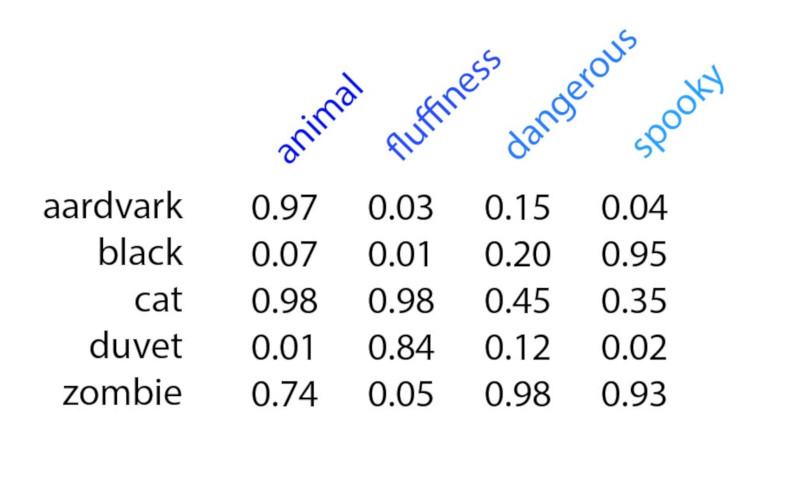

## word2vec: Computing continuous distributed representations of words

En 2013, Mikolov propuso [word2vec](https://code.google.com/archive/p/word2vec/), un algoritmo para aprender embeddings de palabras de manera automática. El proceso consistía en tomar una colección de documentos lo suficientemente grande y representativa de una lengua y aplicar una red neuronal con dos posibles objetivos:

1. tratar de predecir el contexto de aparición a partir de una palabra (**skip-gram**)
2. utilizar el contexto para predecir la palabra en cuestión (**CBOW**: *continuous bag-of-words*)

El resultado final es que el algoritmo aprende a generar vectores de palabras, o *embeddings*, de manera no supervisada: mapeos entre palabras y vectores densos de números reales, que parecen capturar interesantes propiedades lingüísticas, desde el punto de vista semántico y también morfo-sintáctico.

Es muy habitual comparar la similitud entre conceptos calculando el coseno entre los vectores. Dos términos similares tendrán ángulos más cerrados que dos terminos que no lo sean.

![](https://raw.githubusercontent.com/vitojph/1dlstr-embeddings/main/img/simplistic-term-vector-mode.gif)

También podemos utilizar la analogía con las operaciones aritméticas cuando pensamos en estos estos *embeddings*. Si tomamos el conjunto de componentes semánticos de la palabra *París* y, de alguna manera, le quitamos el significado de *Francia*, pero le sumamos el de *España*, el resultado debería ser algo parecido al contenido semántico de la palabra *Madrid*.

    París - Francia + España ≈ Madrid

    comimos - comer + andar ≈ anduvimos


Podemos acceder a los vectores de palabras de word2vec utilizando diversas herramientas. Vamos a ver algunos ejemplos para comprobar, de primera mano, si estas distancias de similitud entre distintos términos están alineados con nuestra intuición o no.

In [17]:
import logging
from gensim.models import Word2Vec

logging.basicConfig(
    format="%(asctime)s : %(levelname)s : %(message)s", level=logging.INFO
)

He entrenado un modelo de word2vec con la Wikipedia en español, [tal y como explico aquí](https://github.com/vitojph/kschool-nlp-23/tree/main/misc).

In [18]:
MODEL = "data/embeddings/eswiki-300.w2v"
w2v = Word2Vec.load(MODEL)

print(f"El modelo contiene {w2v.corpus_count} términos.")

2021-03-13 16:35:48,852 : INFO : loading Word2Vec object from data/embeddings/eswiki-300.w2v
2021-03-13 16:35:50,373 : INFO : loading trainables recursively from data/embeddings/eswiki-300.w2v.trainables.* with mmap=None
2021-03-13 16:35:50,374 : INFO : loading syn1neg from data/embeddings/eswiki-300.w2v.trainables.syn1neg.npy with mmap=None
2021-03-13 16:35:50,793 : INFO : loading vocabulary recursively from data/embeddings/eswiki-300.w2v.vocabulary.* with mmap=None
2021-03-13 16:35:50,793 : INFO : loading wv recursively from data/embeddings/eswiki-300.w2v.wv.* with mmap=None
2021-03-13 16:35:50,794 : INFO : loading vectors from data/embeddings/eswiki-300.w2v.wv.vectors.npy with mmap=None
2021-03-13 16:35:51,217 : INFO : setting ignored attribute vectors_norm to None
2021-03-13 16:35:51,217 : INFO : setting ignored attribute cum_table to None
2021-03-13 16:35:51,218 : INFO : loaded data/embeddings/eswiki-300.w2v


El modelo contiene 41843901 términos.


El objeto `w2v` contiene una enorme matriz de números: una tabla, donde cada fila es uno de los términos del vocabulario reconocido y cada columna es una de las características que permiten modelar el significado de dicho término.

Cada término del vocabulario está representado como un vector con 300 dimensiones. Podemos acceder al vector de un término concreto:

In [19]:
print(w2v.wv["azul"].shape, "\n")
print(w2v.wv["azul"])

(300,) 

[ 6.97230875e-01 -2.16513014e+00  3.48829389e-01 -9.89584625e-01
 -1.02388668e+00 -2.17564240e-01 -1.96011472e+00  2.94649076e+00
 -9.12335694e-01 -6.84771001e-01  1.52577829e+00  7.75085762e-02
 -7.02408105e-02  4.89242375e-01  1.37050912e-01 -9.30723965e-01
  6.80433512e-02 -1.08530678e-01  2.31580353e+00 -5.53485096e-01
 -3.57593626e-01 -2.28935838e+00 -1.50510311e-01  1.26760174e-02
  6.07259810e-01 -2.17627048e+00  2.73906016e+00  1.09757566e+00
 -1.71337926e+00  1.64041713e-01  6.90737784e-01  1.26919913e+00
 -5.12029469e-01 -2.01885894e-01  1.78642869e-01  1.53002536e+00
 -1.43445313e-01  1.11213720e+00 -1.41976345e+00 -1.72563398e+00
  7.15158105e-01  1.11852288e+00 -5.18750012e-01 -7.85638809e-01
 -2.75143218e+00 -2.21702838e+00 -7.32014835e-01 -4.00392205e-01
  1.58708438e-01  1.02694380e+00 -2.80862898e-01  1.41663051e+00
  1.11722755e+00 -1.24235370e-03 -1.14149344e+00 -1.97176194e+00
 -2.22860837e+00 -1.23289347e+00  1.74586341e-01  4.37671602e-01
 -9.38071907e-01

Estos vectores no nos dicen mucho, salvo que contienen números muy pequeños :-/

El mismo objeto permite acceder a una serie de funcionalidades ya implementadas que nos van a permitir evaluar formal e informalmente el modelo. Por el momento, nos contentamos con los segundo: vamos a revisar visualmente los significados que nuestro modelo ha aprendido por su cuenta. 

Podemos calcular la similitud semántica entre dos términos usando el método `wv.similarity`, que nos devuelve un número entre 0 y 1:

In [20]:
print("hombre - mujer", w2v.wv.similarity("hombre", "mujer"))
print("perro - gato", w2v.wv.similarity("perro", "gato"))
print("gato - ladrillo", w2v.wv.similarity("gato", "ladrillo"))
print("febrero - azul", w2v.wv.similarity("febrero", "azul"))

hombre - mujer 0.43087164
perro - gato 0.8005251
gato - ladrillo 0.11610342
febrero - azul -0.021135561


Podemos especificar una lista de términos y elegir el que no encaja, usando el método `wv.doesnt_match`:

In [21]:
l1 = "madrid barcelona gonzález washington".split()
print(f"""en la lista '{" ".join(l1)}' sobra '{w2v.wv.doesnt_match(l1)}'""")

l2 = "madrid barcelona alpedrete marsella".split()
print(f"""en la lista '{" ".join(l2)}' sobra '{w2v.wv.doesnt_match(l2)}'""")

l3 = "publicaron declararon soy fueron negaron".split()
print(f"""en la lista '{" ".join(l3)}' sobra '{w2v.wv.doesnt_match(l3)}'""")

2021-03-13 16:36:19,844 : INFO : precomputing L2-norms of word weight vectors


en la lista 'madrid barcelona gonzález washington' sobra 'washington'
en la lista 'madrid barcelona alpedrete marsella' sobra 'alpedrete'
en la lista 'publicaron declararon soy fueron negaron' sobra 'soy'


Podemos buscar los términos más similares usando el método `wv.most_similar` de nuestro modelo:

In [22]:
for termino in "azul madrid bmw 2020 rock google shakira xiaomi brexit saturno césar lazio".split():
    print(f"{termino} ==> {w2v.wv.most_similar(termino)}\n")

azul ==> [('verde', 0.7170504331588745), ('amarillo', 0.7170424461364746), ('rojo', 0.7002288103103638), ('azúl', 0.6983712315559387), ('turquesa', 0.6890928745269775), ('morado', 0.6765597462654114), ('carmesí', 0.6581361889839172), ('granate', 0.6548363566398621), ('naranja', 0.6507274508476257), ('beige', 0.6397430896759033)]

madrid ==> [('valladolid', 0.7847391366958618), ('barcelona', 0.775865912437439), ('sevilla', 0.760832667350769), ('zaragoza', 0.7517766952514648), ('madrid.', 0.7219818830490112), ('valencia', 0.6873288154602051), ('oviedo', 0.6831979751586914), ('salamanca', 0.6781078577041626), ('málaga', 0.675739049911499), ('pamplona', 0.6748294830322266)]

bmw ==> [('audi', 0.7591230869293213), ('porsche', 0.7583965063095093), ('mercedes-benz', 0.7572087645530701), ('renault', 0.7485953569412231), ('toyota', 0.7476786375045776), ('opel', 0.739383339881897), ('volkswagen', 0.7309398055076599), ('maserati', 0.7237600088119507), ('gt', 0.7185136675834656), ('volvo', 0.71532

Con el mismo método `wv.most_similar` podemos combinar vectores de palabras tratando de jugar con los rasgos semánticos de cada una de ellas para descubrir nuevas relaciones.

In [23]:
print("mujer que ejerce la autoridad en una alcaldía ==> alcalde + mujer - hombre")
most_similar = w2v.wv.most_similar(
    positive=["alcalde", "mujer"], negative=["hombre"], topn=3
)
for item in most_similar:
    print(item)

    
print(
    "mujer especializada en alguna terapia de la medicina ==> doctor + mujer - hombre"
)
most_similar = w2v.wv.most_similar(
    positive=["doctor", "mujer"], negative=["hombre"], topn=3
)
for item in most_similar:
    print(item)

    
print("monarca soberano ==> reina + hombre - mujer")
most_similar = w2v.wv.most_similar(
    positive=["reina", "hombre"], negative=["mujer"], topn=3
)
for item in most_similar:
    print(item)

    
print("capital de Alemania ==> moscú + alemania - rusia")
most_similar = w2v.wv.most_similar(
    positive=["moscú", "alemania"], negative=["rusia"], topn=3
)
for item in most_similar:
    print(item)

mujer que ejerce la autoridad en una alcaldía ==> alcalde + mujer - hombre
('alcaldesa', 0.7252962589263916)
('regidora', 0.6073892116546631)
('concejala', 0.5990710258483887)
mujer especializada en alguna terapia de la medicina ==> doctor + mujer - hombre
('doctora', 0.6626786589622498)
('enfermera', 0.5988627672195435)
('esposa', 0.5201101303100586)
monarca soberano ==> reina + hombre - mujer
('rey', 0.6301776170730591)
('monarca', 0.5567039251327515)
('príncipe', 0.5296465158462524)
capital de Alemania ==> moscú + alemania - rusia
('berlín', 0.7966121435165405)
('múnich', 0.7589867115020752)
('hamburgo', 0.7321966886520386)


## GloVe: Global Vectors for Word Representation

En 2014, Pennington del grupo de NLP de la Universidad de Stanford presentó [GloVe](https://nlp.stanford.edu/projects/glove/), otro algoritmo no supervisado para generar representaciones vectoriales de palabras. 

En este caso, el procedimiento consiste en procesar grandes cantidades de muestras de lengua real y extraer relaciones entre palabras atendiendo a la frecuencia con la que cada par de términos co-ocurren en un corpus. 

Podemos acceder los vectores GloVe con `spaCy`. 

In [24]:
nlp_en = spacy.load("en_core_web_md")

# analizamos algunas colocaciones en inglés
token1, _, token2 = nlp_en("cats and dogs")
token3, _, token4 = nlp_en("research and development")

print(f"los vectores GloVe de spaCy tienen {token1.vector.shape} dimensiones.\n")

print(f"El grado de similitud entre {token1} y {token2} es {token1.similarity(token2)}")
print(f"El grado de similitud entre {token3} y {token4} es {token3.similarity(token4)}")
print(f"El grado de similitud entre {token1} y {token4} es {token1.similarity(token4)}")

los vectores GloVe de spaCy tienen (300,) dimensiones.

El grado de similitud entre cats y dogs es 0.8311763405799866
El grado de similitud entre research y development es 0.5828717350959778
El grado de similitud entre cats y development es 0.10466640442609787


In [25]:
print(token1.vector)

[-0.26763    0.029846  -0.3437    -0.54409   -0.49919    0.15928
 -0.35278   -0.2036     0.23482    1.5671    -0.36458   -0.028713
 -0.27053    0.2504    -0.18126    0.13453    0.25795    0.93213
 -0.12841   -0.18505   -0.57597    0.18538   -0.19147   -0.38465
  0.21656   -0.4387    -0.27846   -0.41339    0.37859   -0.2199
 -0.25907   -0.019796  -0.31885    0.12921    0.22168    0.32671
  0.46943   -0.81922   -0.20031    0.013561  -0.14663    0.14438
  0.0098044 -0.15439    0.21146   -0.28409   -0.4036     0.45355
  0.12173   -0.11516   -0.12235   -0.096467  -0.26991    0.028776
 -0.11307    0.37219   -0.054718  -0.20297   -0.23974    0.86271
  0.25602   -0.3064     0.014714  -0.086497  -0.079054  -0.33109
  0.54892    0.20076    0.28064    0.037788   0.0076729 -0.0050123
 -0.11619   -0.23804    0.33027    0.26034   -0.20615   -0.35744
  0.54125   -0.3239     0.093441   0.17113   -0.41533    0.13702
 -0.21765   -0.65442    0.75733    0.359      0.62492    0.019685
  0.21156    0.28125 

## fastText: Enriching Word Vectors with Subword Information

word2vec y GloVe tienen un problema: solo crean *embeddings* para las palabras que aparecen de manera explícita en el corpus utilizado para el entrenamiento y, en consecuencia, no generar representaciones para palabras raras o desconocidas. ¿Qué hacemos entonces para manejar las *out-of-vocabulary (OOV) words*? Ha habido varias propuestas, que pasaban por ignorarlas completamente o utilizar un vector neutro, calculado a partir del promedio del resto de *embeddings*

fastText (Bojanowski et al., 2016) describe un método para aprender vectores, no de palabras, sino de subcadenas. Esto nos permite aumentar la cobertura de los tokens representados, de manera que vamos a poder representar palabras poco frecuentes e incluso erratas. Para calcular los vectores de una palabra, el procedimiento consiste en sumar los diferentes *embeddings* de todos sus constituyentes.

Los vectores pre-entrenado de fastText [están disponible en 157 lenguas del mundo](https://fasttext.cc/docs/en/crawl-vectors.html).

In [26]:
from gensim.models.wrappers import FastText

In [27]:
ft = FastText.load_fasttext_format("data/embeddings/cc.es.300.bin")

2021-03-13 16:36:56,969 : INFO : loading 2000000 words for fastText model from data/embeddings/cc.es.300.bin
2021-03-13 16:37:48,301 : INFO : loading weights for 2000000 words for fastText model from data/embeddings/cc.es.300.bin
2021-03-13 16:38:51,562 : INFO : loaded (2000000, 300) weight matrix for fastText model from data/embeddings/cc.es.300.bin


In [28]:
print("man - woman", ft.wv.similarity("man", "woman"))
print("cat - dog", ft.wv.similarity("cat", "dog"))
print("cat - brick", ft.wv.similarity("cat", "brick"))
print("February - blue", ft.wv.similarity("February", "blue"))

man - woman 0.58362913
cat - dog 0.4978581
cat - brick 0.16684589
February - blue 0.094084315


In [29]:
l1 = "Madrid Barcelona Gonzalez Washington".split()
print(f"""en la lista '{" ".join(l1)}' sobra '{ft.wv.doesnt_match(l1)}'""")

l2 = "Madrid Barcelona Alpedrete Marseille".split()
print(f"""en la lista '{" ".join(l2)}' sobra '{ft.wv.doesnt_match(l2)}'""")

l3 = "published claimed am were denied".split()
print(f"""en la lista '{" ".join(l3)}' sobra '{ft.wv.doesnt_match(l3)}'""")

2021-03-13 16:39:02,088 : INFO : precomputing L2-norms of word weight vectors
2021-03-13 16:39:06,458 : INFO : precomputing L2-norms of ngram weight vectors


en la lista 'Madrid Barcelona Gonzalez Washington' sobra 'Gonzalez'
en la lista 'Madrid Barcelona Alpedrete Marseille' sobra 'Marseille'
en la lista 'published claimed am were denied' sobra 'am'


In [30]:
most_similar = ft.wv.most_similar(
    positive=["doctor", "woman"], negative=["man"], topn=3
)
for item in most_similar:
    print(item)


most_similar = ft.wv.most_similar(
    positive=["queen", "man"], negative=["woman"], topn=3
)
for item in most_similar:
    print(item)


most_similar = ft.wv.most_similar(
    positive=["Moscow", "Germany"], negative=["Russia"], topn=3
)
for item in most_similar:
    print(item)

('doctora', 0.6434095501899719)
('Doctor', 0.5659758448600769)
('Doctora', 0.5551314949989319)
('king', 0.564818263053894)
('Queen', 0.4771556854248047)
('quee', 0.45482775568962097)
('Munich', 0.5593457221984863)
('Berlin', 0.5453678369522095)
('Germany2', 0.5332241058349609)


In [31]:
for termino in "blue Sun chess boy president HDMI England French mouse plant".split():
    print(f"{termino} ==> {ft.wv.most_similar(termino)}\n")

blue ==> [('yellow', 0.6334750652313232), ('blue.', 0.6216108202934265), ('green', 0.6162960529327393), ('Blue', 0.6128749847412109), ('purple', 0.6056981086730957), ('white', 0.6000158786773682), ('pink', 0.5949622392654419), ('black', 0.5927447080612183), ('silver', 0.579087495803833), ('eyed', 0.562341034412384)]

Sun ==> [('Sun-', 0.6993139386177063), ('Gazing', 0.6198455691337585), ('Moon', 0.6011381149291992), ('Yat-Sen', 0.5826911330223083), ('Tiantian', 0.5822532773017883), ('Rising', 0.5697004795074463), ('Tsogo', 0.564804196357727), ('Risin', 0.5638508796691895), ('Tiberian', 0.5636435151100159), ('Tian-Tian', 0.5625936985015869)]

chess ==> [('chessbase', 0.7376786470413208), ('chesse', 0.6598049402236938), ('Chess', 0.6389083862304688), ('fbchess', 0.6366070508956909), ('chesschamps', 0.5838761329650879), ('chesscom', 0.581561803817749), ('Chessbase', 0.5792803168296814), ('Inforchess', 0.5681726932525635), ('365Chess', 0.5618313550949097), ('chessecake', 0.5519165992736816

# Contextual Word Embeddings

Como hemos visto, algoritmos como word2vec, GloVe o fastText aprenden a calcular de manera no supervisada representaciones continuas de palabras o de segmentos de palabras. Sin embargo, estas representaciones son estáticas y no tienen en cuenta los distintos significados que una misma palabra pueda tener.

Como ya hemos visto, el lenguaje natural está repleto de ambigüedades, a varios niveles, y existen fenómenos como la **polisemia** y la **homografía**, que implican que una misma cadena de caracteres pueda tener más de un significado.

- *banco*: de sentar, de crédito, de peces, de arena
- *cubo*: de agua, operación matemática, figura geométrica
- *planta*: arbusto, fábrica, del pie
- *bajo*: nombre, adjetivo, preposición

¿No sería más lógico asignar diferentes embeddigs teniendo en cuenta los distintos significados?

## ELMo: Embeddings from Language Models

[ELMo](https://allennlp.org/elmo) (Peters et al., 2018) es una nueva técnica del [Allen Institue for AI](https://allennlp.org/) para calcular y asignar vectores de palabras de manera dinámica. ELMo procesa la oración de entrada completa y utiliza dos redes neuronales de tipo LSTM bidireccionales para calcular el *embedding* de cada palabra, atendiendo tanto a su contexto anterior como posterior.

El [entrenamiento de ELMo](https://jalammar.github.io/illustrated-bert/#elmo-context-matters) consiste en entrenar las redes neuronales para predecir cuál es el siguiente token a partir de una determinada secuencia. El **modelo de lenguaje** que aprende a predecir cuál es la siguiente palabra tiene un interesante efecto colateral. El modelo aprende las relaciones lingüísticas de las palabras y las representa como vectores densos que, además: 

- son contextuales, porque la representación que se le asigna a cada palabra viene determinada por su contexto
- son profundas, porque combinan la información de varias capas de una red neuronal de tipo LSTM
- están basadas en caracteres, por lo que pueden manejar más vocabulario

Podemos acceder a estos *embeddings de ELMo* de varias formas, p. ej., a través de `flair`.

In [ ]:
#!pip install -U flair
#!pip install allennlp==0.9.0
#!pip install -U transformers
#!pip install pandas

In [ ]:
from flair.data import Sentence
from flair.embeddings import ELMoEmbeddings

# creamos el vectorizador
vectorizer = ELMoEmbeddings("small")

In [ ]:
import torch

oracion = Sentence("All results on the paper were fine-tuned on a single Cloud TPU.")
# generamos los emeddings para la oración
vectorizer.embed(oracion)

word_embeddings = torch.stack([token.embedding for token in oracion])
print(f"La oración tokenizada con ELMo tiene {len(oracion)} tokens.")
print(f"Cada token se convierte a un vector de tipo {oracion[0].embedding.shape}.")
print(f"Tensor con los vectores de palabras: {word_embeddings.shape}")

# creamos el embedding de la oración promediando los embeddings de los tokens
embedding = torch.mean(word_embeddings, 0)
print(f"El embedding de la oración es de tipo {embedding.shape}")

## BERT: Bidirectional Encoder Representations from Transformers

A finales de 2018, [Google Research presentó BERT](https://github.com/google-research/bert), un modelo de lenguaje basado en la arquitectura de *deep learning* que iba a transformar el mundo del NLP: el [transformer](http://www.peterbloem.nl/blog/transformers). En los meses anteriores se había popularizado un método llamado *Attention* que había tenido mucho impacto en los sistemas de traducción automática. BERT incorpora esta idea para entrenar redes neuronales con mejor rendimiento que con las LSTM.

¿Qué otras características novedosas tiene [BERT](https://github.com/google-research/bert#what-is-bert)?

- Es bidireccional: para generar representaciones de cada palabra se tiene en cuenta tanto el contexto anterior como el posterior. Y no combina dos modelos, uno de izquierda a derecha y otro en sentido contrario. Lo hace de una sola vez.
- Para ello utiliza *masking* en algunos tokens y procesa la oración completa.
- Es capaz de aprender relaciones entre oraciones, porque además de predecir las palabras enmascaradas aprende a predecir las siguiente oración. 

Podemos acceder al modelo pre-entrenado de BERT de varias formas, p. ej., a través de `transformers`.

In [33]:
import torch
from transformers import BertModel, BertTokenizer

MODEL_NAME = "bert-base-cased"
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
model = BertModel.from_pretrained(MODEL_NAME)

text = "All results on the paper were fine-tuned on a single Cloud TPU."
token_ids = tokenizer.encode(text, add_special_tokens=True)
tokens = tokenizer.convert_ids_to_tokens(token_ids, skip_special_tokens=False)

print(tokens)

['[CLS]', 'All', 'results', 'on', 'the', 'paper', 'were', 'fine', '-', 'tuned', 'on', 'a', 'single', 'Cloud', 'T', '##P', '##U', '.', '[SEP]']


In [34]:
print(f"La oración tokenizada con BERT tiene {len(tokens)} tokens.")

input_ids = torch.tensor([token_ids])
# usamos el último estado para representar los vectores de palabras
with torch.no_grad():
    last_hidden_states = model(input_ids)[0]

# creamos el embedding de la oración promediando los embeddings de los tokens
embedding = torch.mean(last_hidden_states, 1)

print(f"Cada token se convierte a un vector de tipo {last_hidden_states[0][0].shape}.")
print(f"Tensor con los vectores de palabras: {last_hidden_states[0].shape}")
print(f"El embedding de la oración es de tipo {embedding[0].shape}")

La oración tokenizada con BERT tiene 19 tokens.
Cada token se convierte a un vector de tipo torch.Size([768]).
Tensor con los vectores de palabras: torch.Size([19, 768])
El embedding de la oración es de tipo torch.Size([768])


## Y más allá

Cada día aparecen nuevos [modelos de lenguaje basados en BERT pre-entrenados en una lengua específica](https://twitter.com/seb_ruder/status/1221851361811128321). Y modelos de lenguaje basados en otras arquitecturas. No es fácil seguir el ritmo.

![](https://raw.githubusercontent.com/vitojph/1dlstr-embeddings/main/img/lm-family.jpg)
